# 전처리 시각화 2 — k-space crop → ESPIRiT 감도맵

원본 fastMRI multi-coil k-space(640×368)를 **이미지 도메인 crop으로 320×320로 만든 뒤**, 그
**cropped k-space에서 ESPIRiT 감도맵을 계산**하는 전체 전처리 과정을 단계별로 봅니다
(우리 `MakeDataset.py`가 하는 것과 동일).

순서: **raw k-space → IFFT → 코일 영상 crop → FFT → cropped k-space → ESPIRiT → 감도맵 → SENSE 결합**

마지막에 `crop` vs `evenodd(홀짝)` 전처리의 감도맵·복원 차이도 비교합니다.

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, h5py
import matplotlib.pyplot as plt 
# importing MakeDataset sets up BART (TOOLBOX_PATH/PATH) and gives the helpers
from MakeDataset import espirit_sens_maps, crop_kspace_slice
from mrrecon.data.transforms import ifft2c_np, fft2c_np, center_crop_2d, rss_np, sense_combine_np

RAW = "/mnt/d/research/MRRecon/multicoil_val"
f = sorted(glob.glob(RAW + "/*.h5"))[0]
with h5py.File(f, "r") as h:
    s = h["kspace"].shape[0] // 2                  # central slice
    kspace_raw = h["kspace"][s]                    # (15, 640, 368) raw multi-coil k-space
    rss_gt = h["reconstruction_rss"][s]            # (320, 320) official GT
C, H, W = kspace_raw.shape
print(f"file {os.path.basename(f)} slice {s}")
print(f"raw k-space {kspace_raw.shape} | official RSS GT {rss_gt.shape}")

# --- 감도맵: full k-space에서 추정 후 crop (FOV-가장자리 artifact 방지) ---
# crop->ecalib 하면 320 readout FOV에서 다리가 끝에 닿아 ESPIRiT가 가장자리 맵을
# 잘못 추정 -> SENSE에 아래쪽 검은 띠. full(640, oversampling 여백)에서 뽑고 자르면 사라짐.
def sens_full_then_crop(n=320):
    return center_crop_2d(espirit_sens_maps(kspace_raw), n)

file file1000000.h5 slice 17
raw k-space (15, 640, 368) | official RSS GT (320, 320)


## 1. 원본 k-space (640 × 368, 15코일)

readout(세로) 640은 2배 oversampling, phase(가로) 368은 phase-FOV. 양 끝 ~18열씩은 zero-padding.

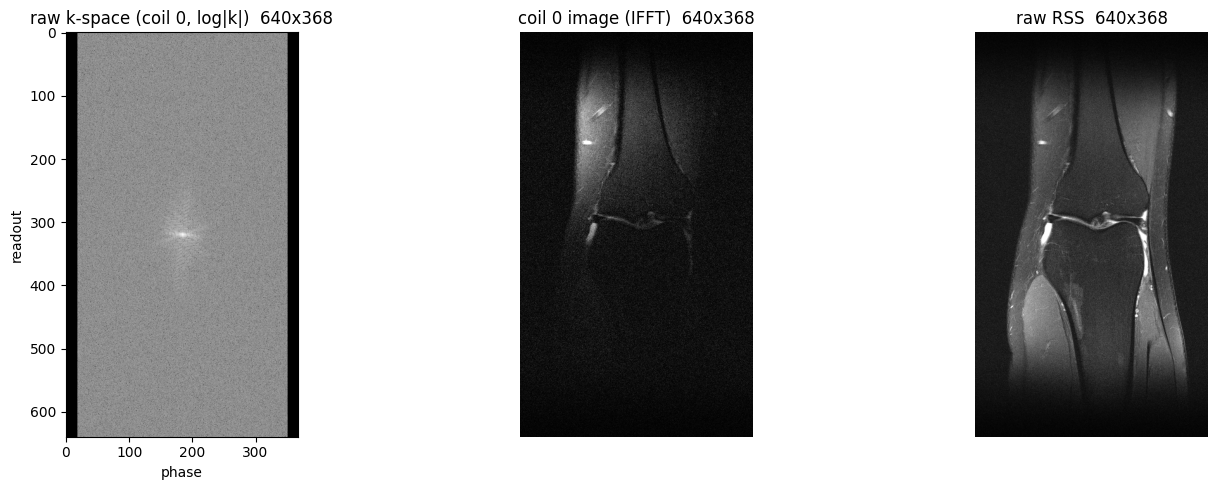

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(np.log(np.abs(kspace_raw[0]) + 1e-9), cmap='gray', aspect='equal')
ax[0].set_title('raw k-space (coil 0, log|k|)  640x368'); ax[0].set_xlabel('phase'); ax[0].set_ylabel('readout')
coil0 = ifft2c_np(kspace_raw[0])                    # one coil image
ax[1].imshow(np.abs(coil0), cmap='gray', aspect='equal', vmax=0.6*np.abs(coil0).max())
ax[1].set_title('coil 0 image (IFFT)  640x368'); ax[1].axis('off')
ax[2].imshow(rss_np(kspace_raw), cmap='gray', aspect='equal', vmax=0.6*rss_np(kspace_raw).max())
ax[2].set_title('raw RSS  640x368'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 2. 이미지 도메인 crop (640×368 → 320×320)

각 코일을 **IFFT → 중앙 320×320 crop → FFT**. readout oversampling 제거 + phase FOV trim.
해상도는 유지되고 FOV만 줄어듭니다 (k-space 라인을 직접 자르는 게 아님).

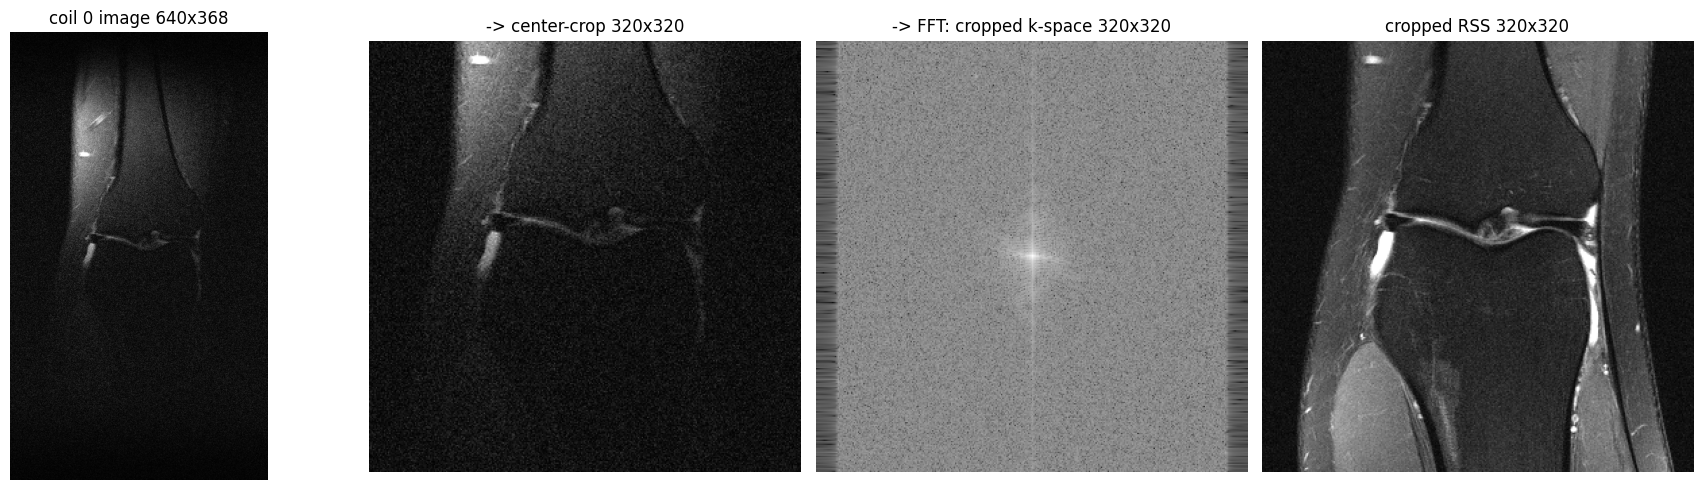

cropped RSS vs official reconstruction_rss : SSIM = 1.0000  (~1.0 이면 완벽 일치)


In [3]:
# per-coil image-domain crop
coil_imgs = ifft2c_np(kspace_raw)                   # (15,640,368) coil images
coil_crop = center_crop_2d(coil_imgs, 320)          # (15,320,320) cropped images
kspace_crop = fft2c_np(coil_crop)                   # (15,320,320) cropped k-space  (== crop_kspace_slice 'crop')

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(np.abs(coil_imgs[0]), cmap='gray', aspect='equal', vmax=0.6*np.abs(coil_imgs[0]).max())
ax[0].set_title('coil 0 image 640x368'); ax[0].axis('off')
ax[1].imshow(np.abs(coil_crop[0]), cmap='gray', vmax=0.6*np.abs(coil_crop[0]).max())
ax[1].set_title('-> center-crop 320x320'); ax[1].axis('off')
ax[2].imshow(np.log(np.abs(kspace_crop[0]) + 1e-9), cmap='gray')
ax[2].set_title('-> FFT: cropped k-space 320x320'); ax[2].axis('off')
ax[3].imshow(rss_np(kspace_crop), cmap='gray', vmax=0.6*rss_np(kspace_crop).max())
ax[3].set_title('cropped RSS 320x320'); ax[3].axis('off')
plt.tight_layout(); plt.show()
# matches official GT?
from mrrecon.metrics import all_metrics, match_scale
ss = all_metrics(rss_gt, match_scale(rss_gt, rss_np(kspace_crop)))['ssim']
print(f"cropped RSS vs official reconstruction_rss : SSIM = {ss:.4f}  (~1.0 이면 완벽 일치)")

## 3. ESPIRiT 감도맵 — **cropped k-space에서** 계산

핵심: 감도맵은 **320×320로 crop한 뒤** 그 k-space에서 BART `ecalib`로 구합니다
(`MakeDataset.save_slice`와 동일 순서). 그래야 맵이 k-space와 같은 320×320 해상도/FOV가 됩니다.

> **⚠️ 감도맵 추출 순서 주의 (아래쪽 검은 띠 해결)**
> `crop → ecalib` 하면 320 readout FOV에서 **다리가 위/아래 끝에 닿아** ESPIRiT가 가장자리 감도맵을
> 잘못 추정 → coil |S| 아래 밝은 띠 → **SENSE combine 아래 검은 띠**가 생깁니다.
> **해결**: full k-space(640, oversampling 여백이 있어 물체가 끝에 안 닿음)에서 감도맵을 추정하고
> **맵을 crop**합니다 (`sens_full_then_crop`). 아래 셀들은 이 방식을 씁니다.

Done.
sens maps (15, 320, 320) complex64


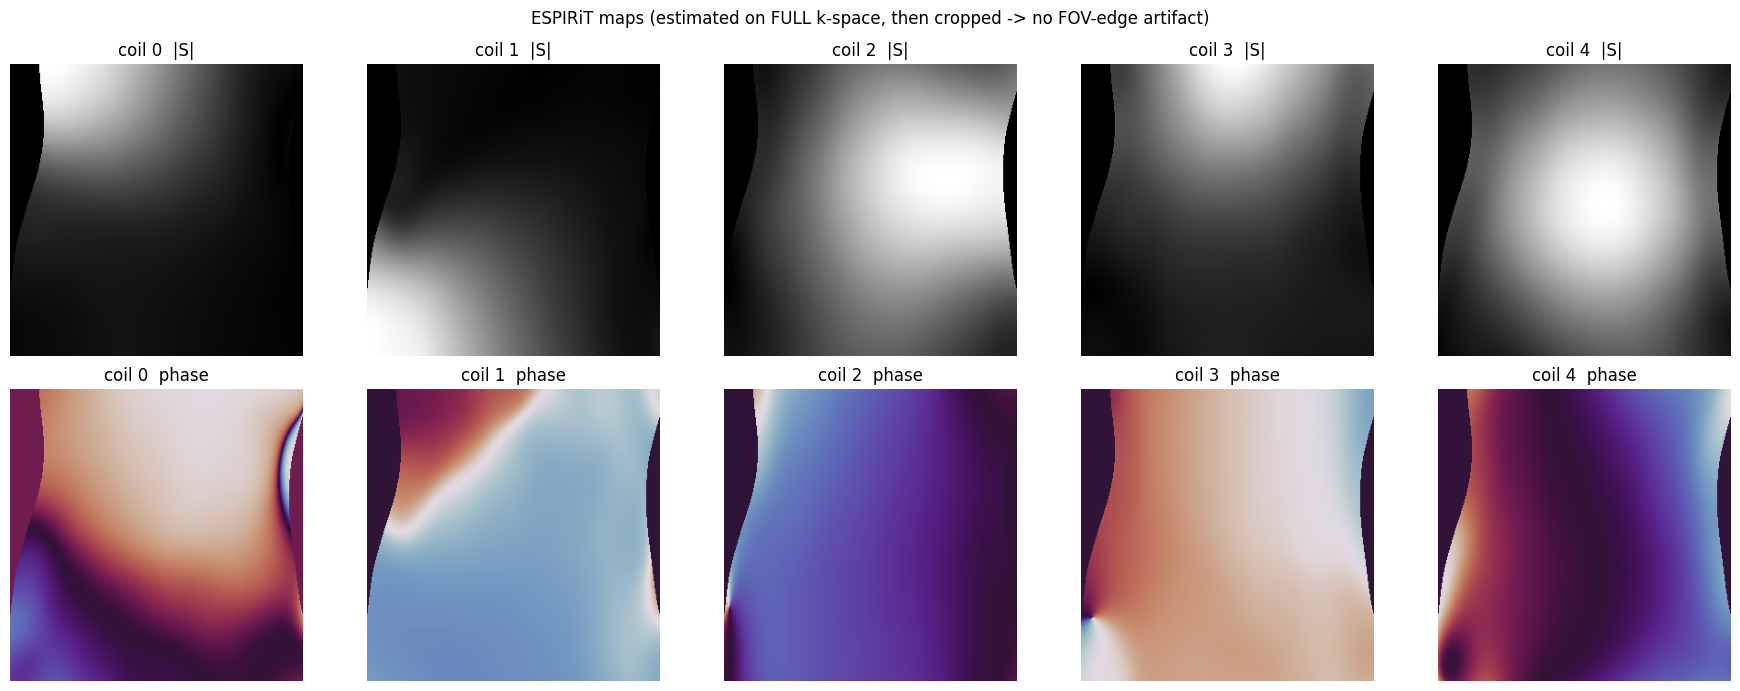

/tmp/ipykernel_928718/3211460900.py:13: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.title('sqrt(Σ_c |S_c|^2)  (≈1 안쪽)'); plt.axis('off'); plt.tight_layout(); plt.show()
/tmp/ipykernel_928718/3211460900.py:13: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.title('sqrt(Σ_c |S_c|^2)  (≈1 안쪽)'); plt.axis('off'); plt.tight_layout(); plt.show()
/home/sonwonjun/anaconda3/envs/Recon/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sonwonjun/anaconda3/envs/Recon/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


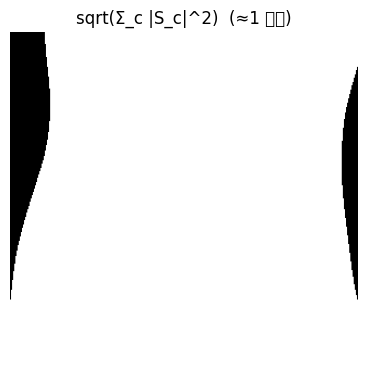

In [4]:
sens = sens_full_then_crop(320)                     # full-ecalib -> crop maps (no FOV-edge artifact)
print('sens maps', sens.shape, sens.dtype)

# show magnitude + phase of a few coil maps
fig, ax = plt.subplots(2, 5, figsize=(18, 7))
for j in range(5):
    ax[0, j].imshow(np.abs(sens[j]), cmap='gray'); ax[0, j].set_title(f'coil {j}  |S|'); ax[0, j].axis('off')
    ax[1, j].imshow(np.angle(sens[j]), cmap='twilight'); ax[1, j].set_title(f'coil {j}  phase'); ax[1, j].axis('off')
plt.suptitle('ESPIRiT maps (estimated on FULL k-space, then cropped -> no FOV-edge artifact)')
plt.tight_layout(); plt.show()
# sanity: RSS of the maps ~ 1 inside the object (well-conditioned)
plt.figure(figsize=(4,4)); plt.imshow(np.sqrt((np.abs(sens)**2).sum(0)), cmap='gray')
plt.title('sqrt(Σ_c |S_c|^2)  (≈1 안쪽)'); plt.axis('off'); plt.tight_layout(); plt.show()

## 4. SENSE 결합 — 감도맵으로 코일 합치기

`SENSE = Σ_c conj(S_c)·IFFT(k_c)`. cropped k-space + 위에서 구한 맵으로 코일 결합한 영상과 RSS 비교.

/tmp/ipykernel_928718/2362223542.py:8: UserWarning: Glyph 50644 (\N{HANGUL SYLLABLE EN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_928718/2362223542.py:8: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_928718/2362223542.py:8: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/sonwonjun/anaconda3/envs/Recon/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50644 (\N{HANGUL SYLLABLE EN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sonwonjun/anaconda3/envs/Recon/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sonwonjun/anaconda3/envs/Recon/lib/python3.10/site-packages/IPython/core/

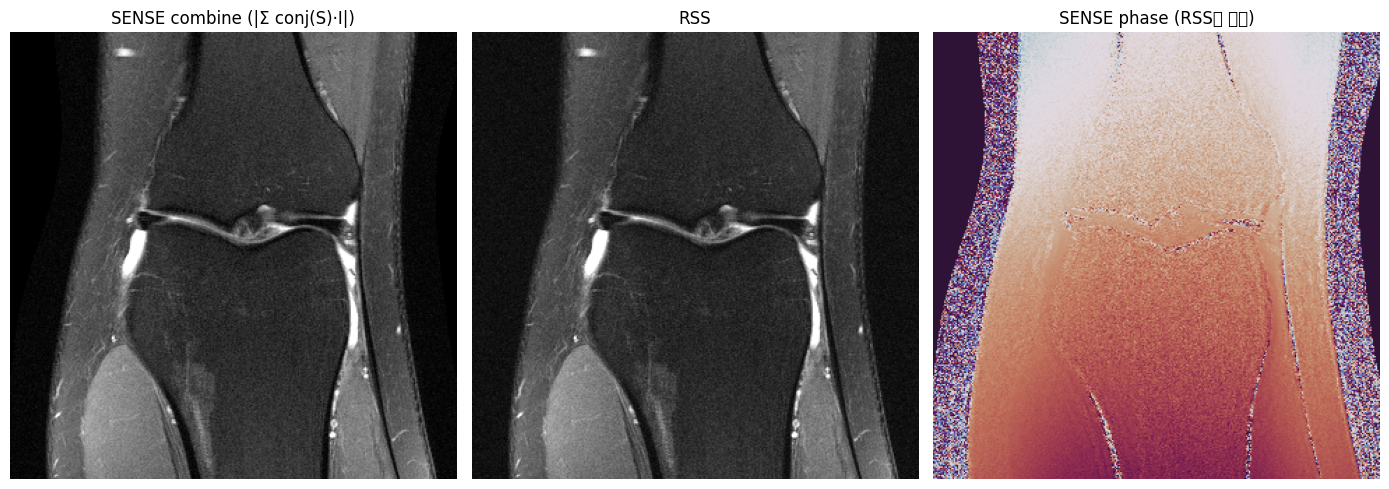

In [5]:
sense_img = sense_combine_np(kspace_crop, sens)     # (320,320) complex
fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(np.abs(sense_img), cmap='gray', vmax=0.6*np.abs(sense_img).max())
ax[0].set_title('SENSE combine (|Σ conj(S)·I|)'); ax[0].axis('off')
ax[1].imshow(rss_np(kspace_crop), cmap='gray', vmax=0.6*rss_np(kspace_crop).max())
ax[1].set_title('RSS'); ax[1].axis('off')
ax[2].imshow(np.angle(sense_img), cmap='twilight'); ax[2].set_title('SENSE phase (RSS엔 없음)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 5. `crop` vs `evenodd(홀짝)` — 감도맵·복원 차이

`evenodd`는 readout k-space를 홀짝으로 솎아내(640→320) FOV가 반으로 줄며 **fold-over aliasing**이
생깁니다. k-space·sens·RSS 모두 같은 evenodd 도메인에서 나와 **자기완결적**이지만, 공식 RSS와는
어긋납니다(SSIM↓). 두 전처리의 감도맵과 RSS를 나란히 비교합니다.

Done.
Done.


/tmp/ipykernel_928718/1886126322.py:17: UserWarning: Glyph 54848 (\N{HANGUL SYLLABLE HOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_928718/1886126322.py:17: UserWarning: Glyph 51677 (\N{HANGUL SYLLABLE JJAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/sonwonjun/anaconda3/envs/Recon/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54848 (\N{HANGUL SYLLABLE HOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sonwonjun/anaconda3/envs/Recon/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51677 (\N{HANGUL SYLLABLE JJAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


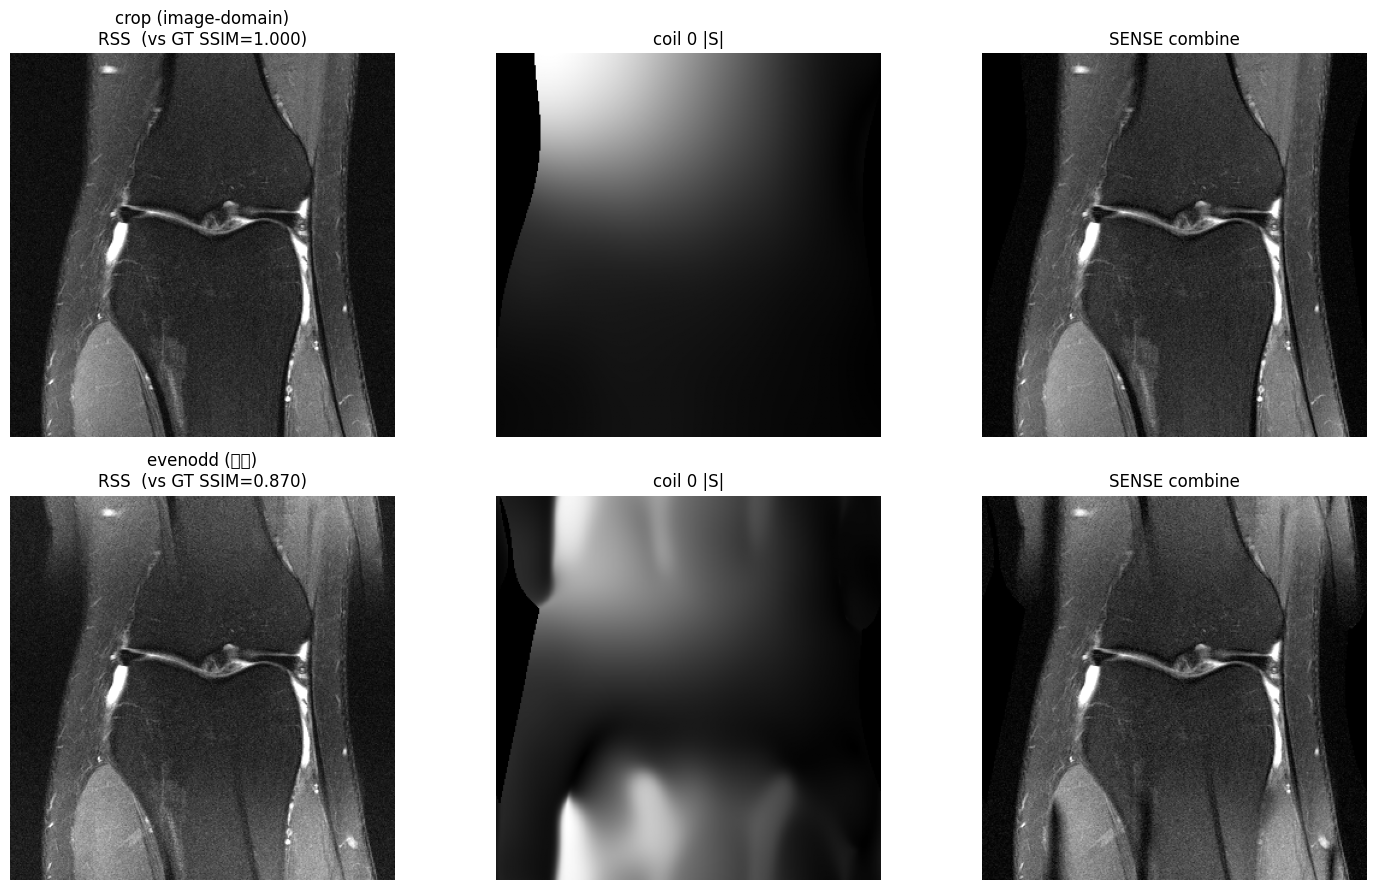

crop    RSS vs official GT : SSIM 1.0000
evenodd RSS vs official GT : SSIM 0.8704  (홀짝은 fold-over로 낮음)


In [6]:
# build both preprocessings via the SAME MakeDataset helper
k_crop = crop_kspace_slice(kspace_raw, 320, 'crop')        # image-domain crop
k_eo   = crop_kspace_slice(kspace_raw, 320, 'evenodd')     # even/odd readout decimation
s_crop = sens_full_then_crop(320)                          # FIX: full-ecalib -> crop maps
s_eo   = espirit_sens_maps(k_eo)

def ssim_vs_gt(k): return all_metrics(rss_gt, match_scale(rss_gt, rss_np(k)))['ssim']
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
for r,(tag,k,sm) in enumerate([('crop (image-domain)', k_crop, s_crop),
                               ('evenodd (홀짝)',       k_eo,   s_eo)]):
    ax[r,0].imshow(rss_np(k), cmap='gray', vmax=0.6*rss_np(k).max())
    ax[r,0].set_title(f'{tag}\nRSS  (vs GT SSIM={ssim_vs_gt(k):.3f})'); ax[r,0].axis('off')
    ax[r,1].imshow(np.abs(sm[0]), cmap='gray'); ax[r,1].set_title('coil 0 |S|'); ax[r,1].axis('off')
    ax[r,2].imshow(np.abs(sense_combine_np(k, sm)), cmap='gray',
                   vmax=0.6*np.abs(sense_combine_np(k, sm)).max())
    ax[r,2].set_title('SENSE combine'); ax[r,2].axis('off')
plt.tight_layout(); plt.show()
print(f"crop    RSS vs official GT : SSIM {ssim_vs_gt(k_crop):.4f}")
print(f"evenodd RSS vs official GT : SSIM {ssim_vs_gt(k_eo):.4f}  (홀짝은 fold-over로 낮음)")

**요약**
- 감도맵은 항상 **320×320로 만든 뒤** 그 k-space에서 ESPIRiT로 계산 (crop·evenodd 모두 동일 순서)
- `crop`(기본): 공식 RSS와 SSIM≈1.0 → 우리 데이터셋이 쓰는 방식
- `evenodd`: 자기완결적이지만 fold-over로 공식 GT와 어긋남(SSIM↓)